# Baseline model for batch monitoring example

In [56]:
import requests
import datetime
import pandas as pd

from joblib import load, dump
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [ ]:
from evidently import DataDefinition
from evidently import Dataset
from evidently import Report
from evidently.metrics import ValueDrift, DriftedColumnsCount, MissingValueCount

ImportError: cannot import name 'ColumnQuantileMetric' from 'evidently.metrics' (/home/avatar/miniconda3/envs/py11/lib/python3.11/site-packages/evidently/metrics/__init__.py)

In [21]:
from evidently.presets import DataSummaryPreset, DataDriftPreset

In [3]:
files = [('green_tripdata_2022-02.parquet', './data'), ('green_tripdata_2022-01.parquet', './data')]

print("Download files:")
for file, path in files:
    url=f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    resp=requests.get(url, stream=True)
    save_path=f"{path}/{file}"
    with open(save_path, "wb") as handle:
        for data in tqdm(resp.iter_content(),
                        desc=f"{file}",
                        postfix=f"save to {save_path}",
                        total=int(resp.headers["Content-Length"])):
            handle.write(data)

Download files:


green_tripdata_2022-01.parquet: 100%|██████████| 1254291/1254291 [00:05<00:00, 235250.94it/s, save to ./data/green_tripdata_2022-01.parquet]


In [4]:
jan_data = pd.read_parquet('data/green_tripdata_2022-01.parquet')

In [5]:
jan_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,62495.000000,62495,62495,56200.000000,62495.000000,62495.000000,56200.000000,62495.000000,62495.000000,62495.00000,62495.000000,62495.000000,62495.000000,62495.000000,62495.000000,56200.000000,56200.000000,56200.000000
mean,1.849508,2022-01-16 14:18:36.026354,2022-01-16 14:37:37.189551,1.198719,97.615041,135.969902,1.258399,77.758632,13.914000,0.34756,0.426322,1.666540,0.208182,0.297312,17.490532,1.403594,1.040925,0.706628
min,1.000000,2009-01-01 00:34:01,2009-01-01 17:05:20,1.000000,1.000000,1.000000,0.000000,0.000000,-65.000000,-4.50000,-0.500000,-0.860000,-6.550000,-0.300000,-71.850000,1.000000,1.000000,0.000000
25%,2.000000,2022-01-08 23:41:50,2022-01-08 23:55:28.500000,1.000000,55.000000,74.000000,1.000000,1.080000,7.000000,0.00000,0.500000,0.000000,0.000000,0.300000,9.360000,1.000000,1.000000,0.000000
50%,2.000000,2022-01-16 15:59:42,2022-01-16 16:17:00,1.000000,75.000000,137.000000,1.000000,1.900000,10.500000,0.00000,0.500000,1.000000,0.000000,0.300000,13.860000,1.000000,1.000000,0.000000
75%,2.000000,2022-01-24 09:16:50,2022-01-24 09:37:28,1.000000,130.000000,215.000000,1.000000,3.500000,17.000000,0.50000,0.500000,2.610000,0.000000,0.300000,21.050000,2.000000,1.000000,2.750000
max,2.000000,2022-01-31 23:57:37,2022-02-01 21:01:54,5.000000,265.000000,265.000000,8.000000,224481.380000,604.500000,4.50000,0.500000,76.770000,44.750000,0.300000,605.300000,5.000000,2.000000,2.750000
std,0.357556,NaN,NaN,0.862313,62.987311,77.590956,0.877743,2909.354163,12.088819,0.65781,0.181381,2.484928,1.257659,0.037201,13.623416,0.516316,0.198119,1.201632


In [6]:
jan_data.shape

(62495, 20)

In [7]:
jan_data["duration_min"] = jan_data.lpep_dropoff_datetime - jan_data.lpep_pickup_datetime
jan_data.duration_min = jan_data.duration_min.apply(lambda td: float(td.total_seconds())/60)

In [8]:
jan_data = jan_data[(jan_data.duration_min >= 0) & (jan_data.duration_min <=60)]

In [9]:
jan_data = jan_data[(jan_data.passenger_count > 0) & (jan_data.passenger_count <= 8)]

<Axes: >

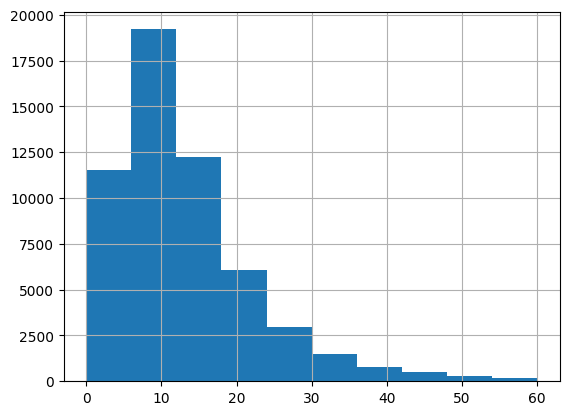

In [10]:
jan_data.duration_min.hist()

In [11]:
target = "duration_min"
num_features = ["passenger_count", "trip_distance", "fare_amount", "total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [12]:
jan_data.shape

(55211, 21)

In [13]:
train_data = jan_data[:30000]
val_data = jan_data[30000:]

In [14]:
model = LinearRegression()

In [15]:
model.fit(train_data[num_features + cat_features], train_data[target])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
train_preds = model.predict(train_data[num_features + cat_features])
train_data['prediction'] = train_preds

In [17]:
val_preds = model.predict(val_data[num_features + cat_features])
val_data['prediction'] = val_preds

In [18]:
print(mean_absolute_error(train_data.duration_min, train_data.prediction))
print(mean_absolute_error(val_data.duration_min, val_data.prediction))

3.8046653737850624
4.142064073688449


# Dump model and reference data

In [19]:
with open('models/lin_reg.bin', 'wb') as f_out:
    dump(model, f_out)

In [20]:
val_data.to_parquet('data/reference.parquet')

# Evidently Report

In [23]:
schema = DataDefinition(
    numerical_columns=num_features,
    categorical_columns=cat_features,
    )

In [24]:

eval_dataset = Dataset.from_pandas(
    val_data[num_features + cat_features],
    data_definition=schema
)

In [25]:
train_dataset = Dataset.from_pandas(
    train_data[num_features + cat_features],
    data_definition=schema
)

In [26]:
report = Report([
    DataSummaryPreset(),
    DataDriftPreset()
],
include_tests="True")

In [27]:
my_eval = report.run(reference_data=train_dataset, current_data=eval_dataset)

In [ ]:
my_eval

In [29]:
from evidently import DataDefinition
from evidently import Dataset
from evidently import Report
from evidently.metrics import ValueDrift, DriftedColumnsCount, MissingValueCount

In [30]:
data_definition = DataDefinition(numerical_columns=num_features + ['prediction'], categorical_columns=cat_features)
train_dataset = Dataset.from_pandas(
    train_data,
    data_definition
)

val_dataset = Dataset.from_pandas(
    val_data,
    data_definition
)

In [31]:
report = Report(metrics=[
    ValueDrift(column='prediction'),
    DriftedColumnsCount(),
    MissingValueCount(column='prediction'),
]
)

In [32]:
snapshot = report.run(reference_data=train_dataset, current_data=val_dataset)


In [ ]:
snapshot

In [38]:
result = snapshot.dict()

In [39]:
result

{'metrics': [{'id': 'bfc6e8246d39abff41fc2e002575d9a3',
   'metric_id': 'ValueDrift(column=prediction)',
   'value': np.float64(0.030493164661663723)},
  {'id': '15e89f895b482f9b84ba7274ed18a106',
   'metric_id': 'DriftedColumnsCount(drift_share=0.5)',
   'value': {'count': 0.0, 'share': 0.0}},
  {'id': 'd57fce37e7dac2a48797649e0e142902',
   'metric_id': 'MissingValueCount(column=prediction)',
   'value': {'count': 0.0, 'share': np.float64(0.0)}}],
 'tests': []}

In [40]:
#prediction drift
result['metrics'][0]['value']

np.float64(0.030493164661663723)

In [41]:
#number of drifted columns
result['metrics'][1]['value']['count']

0.0

In [47]:
#share of missing values
result['metrics'][2]['value']['count']

0.0

# Evidently Dashboard

In [43]:
from evidently.presets import DataDriftPreset, DataSummaryPreset

from evidently.ui.workspace import Workspace
from evidently.sdk.panels import *
from evidently.legacy.renderers.html_widgets import WidgetSize

In [44]:
ws = Workspace("workspace")


In [45]:
project = ws.create_project("NYC Taxi Data Quality Project")
project.description = "My project description"
project.save()

In [ ]:
regular_report = Report(
    metrics=[
        DataSummaryPreset()
    ],
)

data = Dataset.from_pandas(
    val_data.loc[val_data.lpep_pickup_datetime.between('2022-01-28', '2022-01-29', inclusive="left")],
    data_definition=data_definition,
)

regular_snapshot = regular_report.run(current_data=data, timestamp=datetime.datetime(2022,1,28))

regular_snapshot

In [48]:
ws.add_run(project.id, regular_snapshot)

Report ID: 0197ef21-b08e-73d3-8257-fa6df387047d
Link: workspace/0197eca8-599f-751d-9fdc-3fa218943c21/snapshots/0197ef21-b08e-73d3-8257-fa6df387047d.json

In [49]:
#configure the dashboard
project.dashboard.add_panel(
    text_panel(title="NYC taxi data dashboard")
)

project.dashboard.add_panel(
    bar_plot_panel(
        title="Inference Count",
        values=[
            PanelMetric(
                metric="RowCount",
                legend="count",
            ),
        ],
        size="half",
    ),
)

project.dashboard.add_panel(
    line_plot_panel(
        title="Number of Missing Values",
        values=[
            PanelMetric(
                metric="DatasetMissingValueCount",
                legend="count"
            ),
        ],
        size="half",
    ),
)

project.save()

In [ ]:
regular_report = Report(
    metrics=[
        DataSummaryPreset()
    ],
)

data = Dataset.from_pandas(
    val_data.loc[val_data.lpep_pickup_datetime.between('2022-01-29', '2022-01-30', inclusive="left")],
    data_definition=data_definition,
)

regular_run = regular_report.run(current_data=data, timestamp=datetime.datetime(2022,1,29))

regular_run

In [51]:
ws.add_run(project.id, regular_run)

Report ID: 0197ef31-b4e2-74eb-b390-a5fdde24a572
Link: workspace/0197eca8-599f-751d-9fdc-3fa218943c21/snapshots/0197ef31-b4e2-74eb-b390-a5fdde24a572.json

In [63]:
from evidently.metrics import QuantileValue

In [64]:
files = [('green_tripdata_2024-03.parquet', './data')]

print("Download files:")
for file, path in files:
    url=f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    resp=requests.get(url, stream=True)
    save_path=f"{path}/{file}"
    with open(save_path, "wb") as handle:
        for data in tqdm(resp.iter_content(),
                        desc=f"{file}",
                        postfix=f"save to {save_path}",
                        total=int(resp.headers["Content-Length"])):
            handle.write(data)

Download files:


green_tripdata_2024-03.parquet: 100%|██████████| 1372372/1372372 [00:05<00:00, 240573.29it/s, save to ./data/green_tripdata_2024-03.parquet]


In [65]:
march_data = pd.read_parquet('data/green_tripdata_2024-03.parquet')

In [66]:
march_data.shape

(57457, 20)

In [67]:
march_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,57457.000000,57457,57457,55360.000000,57457.000000,57457.000000,55360.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,0.0,57457.000000,57457.000000,55360.000000,55353.000000,55360.000000
mean,1.877334,2024-03-16 04:02:52.405399,2024-03-16 04:21:00.076039,1.179986,95.524688,138.629149,1.309538,13.522828,17.313474,0.904472,0.577410,2.386255,0.192537,NaN,0.979378,22.904832,1.321062,1.038047,0.737730
min,1.000000,2008-12-31 23:02:24,2008-12-31 23:02:30,1.000000,1.000000,1.000000,0.000000,0.000000,-295.080000,-2.500000,-0.500000,-1.560000,0.000000,NaN,-1.000000,-296.080000,1.000000,1.000000,-2.750000
25%,2.000000,2024-03-08 13:53:56,2024-03-08 14:13:49,1.000000,74.000000,74.000000,1.000000,1.100000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,13.440000,1.000000,1.000000,0.000000
50%,2.000000,2024-03-15 22:49:01,2024-03-15 23:09:52,1.000000,75.000000,138.000000,1.000000,1.790000,13.500000,0.000000,0.500000,2.000000,0.000000,NaN,1.000000,18.500000,1.000000,1.000000,0.000000
75%,2.000000,2024-03-23 20:11:25,2024-03-23 20:34:48,1.000000,97.000000,220.000000,1.000000,3.100000,19.800000,1.000000,0.500000,3.610000,0.000000,NaN,1.000000,27.050000,2.000000,1.000000,2.750000
max,2.000000,2024-04-01 00:01:45,2024-04-01 16:11:00,99.000000,265.000000,265.000000,9.000000,125112.200000,841.600000,10.000000,4.250000,150.000000,26.760000,NaN,1.000000,856.980000,5.000000,2.000000,2.750000
std,0.328056,NaN,NaN,1.356719,57.285088,76.295346,0.967749,770.416255,14.958249,1.382446,0.366916,3.159273,1.184551,NaN,0.154253,17.013735,0.497858,0.191311,1.218039


In [ ]:
march_data = march_data[(march_data["lpep_dropoff_datetime"] <= datetime.datetime(2024, 3, 31)) & (march_data["lpep_pickup_datetime"] >= datetime.datetime(2024, 3, 1))]

march_data["day"] = march_data["lpep_pickup_datetime"].dt.day


In [99]:
march_data.groupby("day")["fare_amount"].quantile(0.5)

day
1     13.5
2     13.5
3     14.2
4     12.8
5     13.5
6     12.8
7     13.5
8     13.5
9     13.5
10    14.2
11    12.8
12    13.5
13    13.5
14    14.2
15    13.5
16    14.2
17    13.5
18    13.5
19    13.5
20    12.8
21    13.5
22    13.5
23    12.8
24    14.2
25    13.5
26    13.5
27    13.5
28    13.5
29    13.5
30    14.2
Name: fare_amount, dtype: float64

In [86]:
for day, group in march_data.groupby("day"):
	print(group)

       VendorID lpep_pickup_datetime lpep_dropoff_datetime store_and_fwd_flag  \
0             2  2024-03-01 00:10:52   2024-03-01 00:26:12                  N   
1             2  2024-03-01 00:22:21   2024-03-01 00:35:15                  N   
2             2  2024-03-01 00:45:27   2024-03-01 01:04:32                  N   
3             1  2024-03-01 00:02:00   2024-03-01 00:23:45                  N   
4             2  2024-03-01 00:16:45   2024-03-01 00:23:25                  N   
...         ...                  ...                   ...                ...   
55413         2  2024-03-01 22:12:37   2024-03-01 22:35:38               None   
55414         2  2024-03-01 22:07:00   2024-03-01 22:41:00               None   
55415         2  2024-03-01 22:51:00   2024-03-01 23:03:00               None   
55416         2  2024-03-01 23:19:00   2024-03-01 23:31:00               None   
55417         2  2024-03-01 23:35:00   2024-03-01 23:48:00               None   

       RatecodeID  PULocati

In [ ]:
daily_medians = []



for day, group in march_data.groupby("day"):

    report = Report(metrics=[
        QuantileValue(column="fare_amount", quantile=0.5)
    ])
    snapshot = report.run(reference_data=group, current_data=group)
    




/home/avatar/miniconda3/envs/py11/lib/python3.11/site-packages/evidently/core/datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide

/home/avatar/miniconda3/envs/py11/lib/python3.11/site-packages/evidently/core/datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide

/home/avatar/miniconda3/envs/py11/lib/python3.11/site-packages/evidently/core/datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide

/home/avatar/miniconda3/envs/py11/lib/python3.11/site-packages/evidently/core/datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide

/home/avatar/miniconda3/envs/py11/lib/python3.11/site-packages/evidently/core/datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide

/home/avatar/miniconda3/envs/py11/lib/python3.11/site-packages/evidently/core/datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide

/home/avatar/miniconda3/envs/py11/lib/python3.11/site-packages/e

In [ ]:
    snapshot = report.run(reference_data=group, current_data=group)
    
    result = snapshot.dict()
    median_value = result["metrics"][0]['value']

    daily_medians.append({
        "date": day,
        "median_fare_amount": median_value
    })

median_march_data = pd.DataFrame(daily_medians)

max_median = median_march_data["median_fare_amount"].max()

print(f"Max median: {max_median}")